# BÁO CÁO BÀI TẬP LỚN: DỰ ĐOÁN SỐNG SÓT TITANIC BẰNG MÔ HÌNH PHÂN LOẠI

Notebook xây dựng quy trình phân tích và dự đoán khả năng sống sót của hành khách trên bộ dữ liệu **Titanic**. Biến mục tiêu là `Survived`, trong đó `0` biểu diễn không sống sót và `1` biểu diễn sống sót. Hai mô hình phân loại được so sánh gồm **Logistic Regression** và **Random Forest Classifier**.

## Mục lục

1. [Chuẩn bị môi trường và thư viện](#muc-1)
2. [Nạp bộ dữ liệu Titanic](#muc-2)
3. [Tách biến mục tiêu và loại bỏ định danh](#muc-3)
4. [Kiểm tra và xử lý giá trị thiếu](#muc-4)
5. [Khám phá quan hệ Fare - Age và xử lý ngoại lệ](#muc-5)
6. [Mã hóa biến phân loại bằng One-Hot Encoding](#muc-6)
7. [Chia tập dữ liệu và chuẩn hóa đặc trưng](#muc-7)
8. [Phân tích tương quan với biến sống sót](#muc-8)
9. [Huấn luyện và đánh giá mô hình Logistic Regression](#muc-9)
10. [Huấn luyện và đánh giá mô hình Random Forest Classifier](#muc-10)
11. [So sánh kết quả và kết luận bài toán phân loại](#muc-11)


<a id="muc-1"></a>
## 1. Chuẩn bị môi trường và thư viện

Import các thư viện xử lý dữ liệu, trực quan hóa và xây dựng mô hình phân loại; thiết lập giao diện biểu đồ bằng `seaborn`.


In [ ]:
# Import NumPy để hỗ trợ tính toán số học và xử lý mảng.
import numpy as np
# Import pandas để đọc file CSV, tạo DataFrame và xử lý dữ liệu dạng bảng.
import pandas as pd
# Import matplotlib để vẽ biểu đồ cơ bản.
import matplotlib.pyplot as plt
# Import seaborn để vẽ biểu đồ thống kê đẹp và dễ đọc hơn.
import seaborn as sns

# Hàm train_test_split dùng để chia dữ liệu thành tập huấn luyện và tập validation.
from sklearn.model_selection import train_test_split
# StandardScaler dùng để chuẩn hóa các đặc trưng về cùng thang đo.
from sklearn.preprocessing import StandardScaler
# LogisticRegression là mô hình phân loại tuyến tính, dùng làm mô hình cơ sở.
from sklearn.linear_model import LogisticRegression
# RandomForestClassifier là mô hình rừng ngẫu nhiên, dùng để học quan hệ phi tuyến tốt hơn.
from sklearn.ensemble import RandomForestClassifier
# Các hàm đánh giá mô hình phân loại: accuracy, báo cáo phân loại và ma trận nhầm lẫn.
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Thiết lập phong cách biểu đồ seaborn để các hình vẽ có nền lưới trắng và cỡ chữ dễ đọc.
sns.set(style="whitegrid", font_scale=1.0)


<a id="muc-2"></a>
## 2. Nạp bộ dữ liệu Titanic

Đọc file `train.csv` của bộ dữ liệu Titanic, hiển thị năm dòng đầu tiên và kích thước dữ liệu gốc để nắm cấu trúc ban đầu của bảng dữ liệu.


In [ ]:
# Đường dẫn đến file train.csv của Titanic trong môi trường đang sử dụng.
filepath = "/content/drive/MyDrive/BTL_MC/Dự đoán sống sót Titanic/train.csv"

# Đọc dữ liệu từ file CSV vào DataFrame df.
df = pd.read_csv(filepath)

# In tiêu đề để người đọc biết output bên dưới là 5 dòng dữ liệu đầu tiên.
print("5 dòng đầu:")
# Hiển thị 5 dòng đầu tiên nhằm quan sát nhanh cấu trúc cột và kiểu dữ liệu ban đầu.
display(df.head())
# In kích thước dữ liệu theo dạng (số dòng, số cột).
print("Kích thước dữ liệu gốc:", df.shape)


5 dòng đầu:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Kích thước dữ liệu gốc: (891, 12)


### Output thu được và nhận xét dữ liệu

**Cách đọc output**

Output đầu tiên là bảng `df.head()`, gồm 5 hành khách đầu tiên trong dữ liệu. Mỗi dòng tương ứng một hành khách; mỗi cột mô tả một thuộc tính như hạng vé, tên, giới tính, tuổi, số người thân đi cùng, giá vé và cảng lên tàu. Cột `Survived` là nhãn cần dự đoán: `0` nghĩa là không sống sót, `1` nghĩa là sống sót.

**Kết quả hiển thị**

| Nội dung | Kết quả |
|---|---:|
| Số quan sát | 891 |
| Tổng số cột | 12 |
| Biến cần dự đoán | `Survived` |

Bảng 5 dòng đầu giúp kiểm tra dữ liệu đã đọc đúng file và đúng cấu trúc. Ví dụ, có cả biến số (`Age`, `Fare`, `SibSp`, `Parch`) và biến phân loại (`Name`, `Sex`, `Ticket`, `Cabin`, `Embarked`). Điều này cho thấy notebook cần xử lý cả missing values và biến phân loại trước khi đưa vào mô hình.

Dòng `Kích thước dữ liệu gốc: (891, 12)` cho biết tập train có **891 hành khách** và **12 cột**. Đây là dữ liệu có nhãn, vì vậy phù hợp để chia thành tập huấn luyện và validation nhằm đánh giá mô hình.

**Kết luận:** Dữ liệu ban đầu phù hợp cho bài toán phân loại nhị phân, nhưng cần xử lý giá trị thiếu, loại bỏ cột định danh không cần thiết và mã hóa biến phân loại trước khi huấn luyện mô hình.


<a id="muc-3"></a>
## 3. Tách biến mục tiêu và loại bỏ định danh

Tách `Survived` thành biến mục tiêu `y`, đồng thời loại bỏ `Survived` và `PassengerId` khỏi tập đặc trưng. `PassengerId` chỉ là mã định danh hành khách nên không mang ý nghĩa dự báo trực tiếp.


In [ ]:
# Tạo bản sao của dữ liệu gốc để xử lý, tránh làm thay đổi trực tiếp DataFrame df ban đầu.
dfprocessed = df.copy()

# Lấy cột Survived làm biến mục tiêu y vì đây là nhãn cần dự đoán.
y = dfprocessed["Survived"]
# Loại bỏ Survived khỏi tập đặc trưng để tránh rò rỉ nhãn; loại PassengerId vì chỉ là mã định danh.
dfprocessed = dfprocessed.drop(["Survived", "PassengerId"], axis=1)

# In kích thước tập đặc trưng sau khi bỏ nhãn và PassengerId.
print("Shape dfprocessed sau tách target:", dfprocessed.shape)
# In kích thước vector nhãn để kiểm tra số mẫu của y khớp với số dòng dữ liệu.
print("Shape y:", y.shape)


Shape dfprocessed sau tách target: (891, 10)
Shape y: (891,)


### Output thu được và nhận xét tách nhãn

**Cách đọc output**

`dfprocessed` là tập đặc trưng đầu vào sau khi bỏ cột nhãn `Survived` và cột định danh `PassengerId`. `y` là vector nhãn chứa kết quả sống sót thật của từng hành khách.

**Kết quả hiển thị**

| Thành phần | Kích thước | Ý nghĩa |
|---|---:|---|
| Tập thuộc tính `dfprocessed` | `(891, 10)` | 891 hành khách, 10 đặc trưng còn lại |
| Vector nhãn `y` | `(891,)` | 891 nhãn sống sót/không sống sót |

Số dòng của `dfprocessed` và `y` đều bằng **891**, chứng tỏ sau khi tách nhãn không bị lệch dữ liệu. Mỗi dòng đặc trưng vẫn khớp với đúng một nhãn trong `y`.

Việc loại `PassengerId` là hợp lý vì đây chỉ là mã thứ tự hành khách, không phải thông tin mô tả khả năng sống sót. Nếu giữ lại, mô hình có thể học nhiễu từ mã định danh thay vì học quy luật thật.

**Kết luận:** Biến mục tiêu đã được tách đúng, tập đặc trưng không còn chứa nhãn nên tránh được rò rỉ dữ liệu trực tiếp vào mô hình.


<a id="muc-4"></a>
## 4. Kiểm tra và xử lý giá trị thiếu

Thống kê số lượng giá trị thiếu trên từng cột, sau đó xử lý theo kiểu dữ liệu: `Cabin` được điền bằng `None`, các biến số như `Age` và `Fare` được điền bằng trung vị, còn biến phân loại được điền bằng giá trị xuất hiện nhiều nhất.


In [ ]:
# In tiêu đề cho bảng thống kê giá trị thiếu trước khi xử lý.
print("Số giá trị thiếu ban đầu:")
# Đếm số giá trị thiếu ở từng cột và chỉ hiển thị các cột có số lượng thiếu lớn hơn 0.
display(dfprocessed.isnull().sum()[dfprocessed.isnull().sum() > 0])

# Duyệt qua các cột mà giá trị thiếu có thể hiểu là không có thông tin tương ứng.
for col in ["Cabin"]:
    # Kiểm tra cột có tồn tại trong DataFrame trước khi xử lý để tránh lỗi.
    if col in dfprocessed.columns:
        # Điền NaN của Cabin bằng chuỗi "None" để giữ ý nghĩa hành khách không có dữ liệu khoang.
        dfprocessed[col] = dfprocessed[col].fillna("None")

# Duyệt qua các cột số quan trọng có thể bị thiếu.
for col in ["Age", "Fare"]:
    # Chỉ xử lý nếu cột tồn tại trong dữ liệu.
    if col in dfprocessed.columns:
        # Điền giá trị thiếu bằng trung vị để giảm ảnh hưởng của các giá trị ngoại lệ.
        dfprocessed[col] = dfprocessed[col].fillna(dfprocessed[col].median())

# Duyệt qua toàn bộ các cột dạng chuỗi còn lại.
for col in dfprocessed.select_dtypes(include="object").columns:
    # Điền giá trị thiếu của biến phân loại bằng mode, tức giá trị xuất hiện nhiều nhất.
    dfprocessed[col] = dfprocessed[col].fillna(dfprocessed[col].mode()[0])

# Duyệt qua toàn bộ các cột số còn lại.
for col in dfprocessed.select_dtypes(include=["int64", "float64"]).columns:
    # Nếu vẫn còn thiếu ở biến số, điền bằng 0 như phương án dự phòng.
    dfprocessed[col] = dfprocessed[col].fillna(0)

# In tiêu đề để kiểm tra lại dữ liệu sau xử lý missing values.
print("Các cột còn giá trị thiếu sau khi xử lý:")
# Tính lại số lượng giá trị thiếu sau khi đã điền dữ liệu.
missing_after = dfprocessed.isnull().sum()
# Chỉ hiển thị các cột vẫn còn thiếu; nếu output rỗng nghĩa là đã xử lý hết.
display(missing_after[missing_after > 0])


Số giá trị thiếu ban đầu:


,0
Age,177
Cabin,687
Embarked,2


Các cột còn giá trị thiếu sau khi xử lý:


,0


### Output thu được và nhận xét giá trị thiếu

**Cách đọc output**

Bảng đầu tiên liệt kê các cột có giá trị thiếu trước khi xử lý. Chỉ những cột có số lượng thiếu lớn hơn 0 mới được hiển thị. Bảng sau xử lý nếu rỗng nghĩa là không còn missing values.

**Giá trị thiếu ban đầu**

| Cột | Số giá trị thiếu | Cách xử lý |
|---|---:|---|
| `Age` | 177 | Điền bằng trung vị của tuổi |
| `Cabin` | 687 | Điền bằng chuỗi `None` |
| `Embarked` | 2 | Điền bằng mode, tức cảng xuất hiện nhiều nhất |

`Cabin` thiếu nhiều nhất, nhưng việc điền `None` giúp giữ lại thông tin rằng hành khách không có dữ liệu khoang. Với `Age`, trung vị phù hợp hơn trung bình vì tuổi có thể có ngoại lệ. Với `Embarked`, số lượng thiếu rất ít nên điền bằng mode không làm thay đổi đáng kể phân phối dữ liệu.

Output sau xử lý hiển thị danh sách rỗng, nghĩa là toàn bộ cột đã hết giá trị thiếu. Đây là điều kiện cần trước khi mã hóa và huấn luyện, vì nhiều mô hình scikit-learn không nhận trực tiếp dữ liệu chứa `NaN`.

**Kết luận:** Sau xử lý, không còn cột thiếu dữ liệu; toàn bộ 891 quan sát ban đầu sẵn sàng cho bước khám phá và mã hóa.


<a id="muc-5"></a>
## 5. Khám phá quan hệ Fare - Age và xử lý ngoại lệ

Trực quan hóa quan hệ giữa giá vé `Fare` và tuổi `Age` để nhận diện điểm bất thường. Notebook loại bỏ các quan sát có `Fare >= 500` nhằm giảm ảnh hưởng của những vé cực cao lên mô hình.


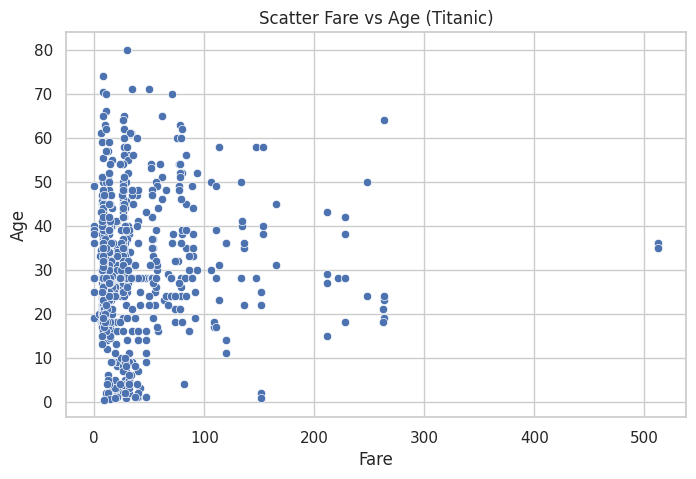

Shape dfprocessed sau khi bỏ outlier: (888, 10)
Shape y sau khi bỏ outlier: (888,)


In [ ]:
# Tạo khung hình kích thước 8x5 inch cho biểu đồ phân tán.
plt.figure(figsize=(8, 5))
# Vẽ biểu đồ scatter để xem mối quan hệ giữa giá vé Fare và tuổi Age.
sns.scatterplot(x=dfprocessed["Fare"], y=dfprocessed["Age"])
# Đặt tiêu đề biểu đồ.
plt.title("Scatter Fare vs Age (Titanic)")
# Đặt nhãn cho trục hoành.
plt.xlabel("Fare")
# Đặt nhãn cho trục tung.
plt.ylabel("Age")
# Hiển thị biểu đồ.
plt.show()

# Lấy index của các dòng có Fare nhỏ hơn 500, tức giữ lại các vé không thuộc nhóm cực cao.
indices_to_keep = dfprocessed[dfprocessed["Fare"] < 500].index

# Lọc tập đặc trưng theo các index được giữ lại.
dfprocessed = dfprocessed.loc[indices_to_keep]
# Lọc vector nhãn y theo cùng index để đảm bảo nhãn vẫn khớp với từng dòng dữ liệu.
y = y.loc[indices_to_keep]

# In kích thước tập đặc trưng sau khi loại ngoại lệ.
print("Shape dfprocessed sau khi bỏ outlier:", dfprocessed.shape)
# In kích thước vector nhãn sau khi loại ngoại lệ để kiểm tra vẫn khớp số mẫu.
print("Shape y sau khi bỏ outlier:", y.shape)


### Phân tích output trực quan hóa và xử lý ngoại lệ

**Cách đọc biểu đồ**

Biểu đồ scatter có trục hoành là `Fare` và trục tung là `Age`. Mỗi điểm là một hành khách. Phần lớn điểm nằm ở vùng giá vé thấp đến trung bình, trong khi một vài điểm có `Fare` rất cao, tách xa khỏi cụm dữ liệu chính.

Notebook dùng ngưỡng `Fare < 500` để giữ lại các quan sát thông thường và loại các vé cực cao. Sau khi lọc, kích thước dữ liệu giảm từ **891** xuống **888** mẫu.

**Kết quả hiển thị**

| Trạng thái | Số mẫu | Số thuộc tính | Ý nghĩa |
|---|---:|---:|---|
| Trước khi lọc | 891 | 10 | Dữ liệu sau tách nhãn và xử lý thiếu |
| Sau khi lọc `Fare < 500` | 888 | 10 | Dữ liệu sau khi bỏ vé cực cao |
| Số mẫu bị loại | 3 | - | Nhóm ngoại lệ theo giá vé |

Tỷ lệ mẫu bị loại chỉ khoảng **0,34%**, nên quy mô dữ liệu gần như không đổi. Việc lọc này giúp giảm ảnh hưởng của một số điểm quá xa khi chuẩn hóa và huấn luyện mô hình.

Dòng `Shape y sau khi bỏ outlier: (888,)` xác nhận vector nhãn cũng đã được lọc theo cùng index. Đây là điểm quan trọng vì nếu chỉ lọc `dfprocessed` mà không lọc `y`, đặc trưng và nhãn sẽ bị lệch nhau.

**Kết luận:** Việc loại ngoại lệ theo `Fare` giữ lại gần như toàn bộ dữ liệu, đồng thời làm tập dữ liệu ổn định hơn cho mô hình phân loại.


<a id="muc-6"></a>
## 6. Mã hóa biến phân loại bằng One-Hot Encoding

Các cột dạng chuỗi như `Name`, `Sex`, `Ticket`, `Cabin` và `Embarked` được chuyển sang dạng số bằng One-Hot Encoding với `drop_first=True`, giúp mô hình học máy có thể sử dụng các biến phân loại.


In [ ]:
# Chọn ra các cột có kiểu object, đây là các biến phân loại cần chuyển sang dạng số.
categorical_cols = dfprocessed.select_dtypes(include="object").columns
# In danh sách các cột sẽ được One-Hot Encoding để người đọc biết dữ liệu nào được mã hóa.
print("Các cột phân loại sẽ được One-Hot:", list(categorical_cols))

# Chuyển biến phân loại thành nhiều cột nhị phân; drop_first=True giúp bỏ một mức tham chiếu để giảm dư thừa.
dfprocessed = pd.get_dummies(dfprocessed, columns=categorical_cols, drop_first=True)

# In kích thước dữ liệu sau khi mã hóa để thấy số cột đã tăng lên bao nhiêu.
print("Shape dfprocessed sau One-Hot:", dfprocessed.shape)
# Hiển thị 5 dòng đầu sau mã hóa để kiểm tra dữ liệu đã ở dạng số/boolean.
display(dfprocessed.head())


Các cột phân loại sẽ được One-Hot: ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']
Shape dfprocessed sau One-Hot: (888, 1720)


,Pclass,Age,SibSp,Parch,Fare,"Name_Abbott, Mr. Rossmore Edward","Name_Abbott, Mrs. Stanton (Rosa Hunt)","Name_Abelson, Mr. Samuel","Name_Abelson, Mrs. Samuel (Hannah Wizosky)","Name_Adahl, Mr. Mauritz Nils Martin",...,Cabin_F G73,Cabin_F2,Cabin_F33,Cabin_F38,Cabin_F4,Cabin_G6,Cabin_None,Cabin_T,Embarked_Q,Embarked_S
0,3,22.0,1,0,7.2500,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True
1,1,38.0,1,0,71.2833,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,3,26.0,0,0,7.9250,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True
3,1,35.0,1,0,53.1000,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,3,35.0,0,0,8.0500,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True


### Output thu được và nhận xét mã hóa biến phân loại

**Cách đọc output**

Dòng đầu tiên in ra danh sách các cột dạng chuỗi được đưa vào One-Hot Encoding. Sau đó, `Shape dfprocessed sau One-Hot` cho biết số cột mới sau khi các biến phân loại được tách thành nhiều cột nhị phân.

**Kết quả hiển thị**

| Nội dung | Kết quả | Ý nghĩa |
|---|---:|---|
| Các cột được One-Hot | `Name`, `Sex`, `Ticket`, `Cabin`, `Embarked` | Các biến ban đầu không phải dạng số |
| Kích thước sau One-Hot | `(888, 1720)` | 888 mẫu và 1720 đặc trưng sau mã hóa |

Số cột tăng mạnh vì `Name`, `Ticket` và `Cabin` có nhiều giá trị khác nhau. Ví dụ, mỗi tên hành khách hoặc mã vé hiếm có thể tạo thành một cột riêng. Các cột mới thường có giá trị `True/False` hoặc `0/1`, thể hiện hành khách có thuộc nhóm đó hay không.

Bảng `dfprocessed.head()` sau mã hóa giúp kiểm tra rằng dữ liệu đã không còn cột chữ gốc. Đây là bước bắt buộc vì các mô hình như Logistic Regression và Random Forest trong scikit-learn cần đầu vào dạng số.

**Lưu ý báo cáo:** Việc đưa trực tiếp `Name` và `Ticket` vào One-Hot tạo nhiều cột hiếm. Trong hướng phát triển, có thể trích xuất đặc trưng có ý nghĩa hơn như danh xưng từ `Name` hoặc nhóm tiền tố vé từ `Ticket`.

**Kết luận:** Dữ liệu đã chuyển hoàn toàn về dạng số, đủ điều kiện đưa vào các mô hình của scikit-learn.


<a id="muc-7"></a>
## 7. Chia tập dữ liệu và chuẩn hóa đặc trưng

Chia dữ liệu theo tỷ lệ 80% huấn luyện và 20% validation với `random_state=42`. Tham số `stratify=y` giữ tỷ lệ sống sót/không sống sót tương đối ổn định giữa hai tập. Các đặc trưng được chuẩn hóa bằng `StandardScaler`, trong đó scaler chỉ được khớp trên tập huấn luyện.


In [ ]:
# Chia dữ liệu thành tập train và validation theo tỷ lệ 80% - 20%.
X_train, X_val, y_train, y_val = train_test_split(
    # dfprocessed là ma trận đặc trưng đầu vào.
    dfprocessed,
    # y là vector nhãn Survived tương ứng với từng hành khách.
    y,
    # test_size=0.2 nghĩa là 20% dữ liệu được dùng làm tập validation.
    test_size=0.2,
    # random_state giúp kết quả chia dữ liệu có thể lặp lại.
    random_state=42,
    # stratify=y giữ tỷ lệ hai lớp 0/1 gần giống nhau giữa train và validation.
    stratify=y
)

# In kích thước tập đặc trưng huấn luyện.
print("Kích thước X_train:", X_train.shape)
# In kích thước tập đặc trưng validation.
print("Kích thước X_val:", X_val.shape)
# In kích thước nhãn huấn luyện.
print("Kích thước y_train:", y_train.shape)
# In kích thước nhãn validation.
print("Kích thước y_val:", y_val.shape)

# Khởi tạo bộ chuẩn hóa StandardScaler.
scaler = StandardScaler()
# Fit scaler trên tập train và biến đổi X_train sang thang đo chuẩn hóa.
X_train_scaled = scaler.fit_transform(X_train)
# Chỉ transform tập validation bằng scaler đã học từ train để tránh data leakage.
X_val_scaled = scaler.transform(X_val)

# Chuyển mảng numpy sau chuẩn hóa về DataFrame, giữ lại tên cột và index ban đầu của X_train.
X_train = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
# Chuyển X_val sau chuẩn hóa về DataFrame, giữ lại tên cột và index ban đầu của X_val.
X_val = pd.DataFrame(X_val_scaled, columns=X_val.columns, index=X_val.index)

# In tiêu đề cho bảng dữ liệu sau chuẩn hóa.
print("5 dòng đầu X_train sau chuẩn hóa:")
# Hiển thị 5 dòng đầu của X_train để kiểm tra các giá trị đã được đưa về quanh 0.
display(X_train.head())


Kích thước X_train: (710, 1720)
Kích thước X_val: (178, 1720)
Kích thước y_train: (710,)
Kích thước y_val: (178,)
5 dòng đầu X_train sau chuẩn hóa:


,Pclass,Age,SibSp,Parch,Fare,"Name_Abbott, Mr. Rossmore Edward","Name_Abbott, Mrs. Stanton (Rosa Hunt)","Name_Abelson, Mr. Samuel","Name_Abelson, Mrs. Samuel (Hannah Wizosky)","Name_Adahl, Mr. Mauritz Nils Martin",...,Cabin_F G73,Cabin_F2,Cabin_F33,Cabin_F38,Cabin_F4,Cabin_G6,Cabin_None,Cabin_T,Embarked_Q,Embarked_S
618,-0.381593,-1.931902,1.412254,0.751452,0.226984,-0.037556,0.0,-0.037556,-0.037556,-0.037556,...,-0.037556,-0.06514,-0.053149,0.0,18.814888,-0.075271,-1.924055,-0.037556,-0.292621,0.602299
481,-0.381593,-0.110137,-0.465462,-0.458369,-0.747198,-0.037556,0.0,-0.037556,-0.037556,-0.037556,...,-0.037556,-0.06514,-0.053149,0.0,-0.053149,-0.075271,0.519736,-0.037556,-0.292621,0.602299
527,-1.591107,-0.110137,-0.465462,-0.458369,4.792626,-0.037556,0.0,-0.037556,-0.037556,-0.037556,...,-0.037556,-0.06514,-0.053149,0.0,-0.053149,-0.075271,-1.924055,-0.037556,-0.292621,0.602299
435,-1.591107,-1.172833,0.473396,1.961273,2.250283,-0.037556,0.0,-0.037556,-0.037556,-0.037556,...,-0.037556,-0.06514,-0.053149,0.0,-0.053149,-0.075271,-1.924055,-0.037556,-0.292621,0.602299
801,-0.381593,0.117584,0.473396,0.751452,-0.091499,-0.037556,0.0,-0.037556,-0.037556,-0.037556,...,-0.037556,-0.06514,-0.053149,0.0,-0.053149,-0.075271,0.519736,-0.037556,-0.292621,0.602299


### Output thu được và nhận xét chia tập, chuẩn hóa

**Cách đọc output**

Bốn dòng kích thước cho biết số mẫu và số đặc trưng ở từng tập sau khi chia dữ liệu. `X_train` và `X_val` là đặc trưng; `y_train` và `y_val` là nhãn tương ứng.

**Kết quả chia dữ liệu**

| Tập dữ liệu | Kích thước | Vai trò |
|---|---:|---|
| `X_train` | `(710, 1720)` | Huấn luyện mô hình |
| `X_val` | `(178, 1720)` | Đánh giá mô hình |
| `y_train` | `(710,)` | Nhãn huấn luyện |
| `y_val` | `(178,)` | Nhãn đánh giá |

Tổng số mẫu là `710 + 178 = 888`, đúng bằng dữ liệu sau khi lọc ngoại lệ. Việc dùng `stratify=y` giúp tỷ lệ lớp sống sót và không sống sót trong tập validation gần giống tập dữ liệu ban đầu, nhờ đó đánh giá mô hình công bằng hơn.

`StandardScaler` đưa các cột về thang đo chuẩn hóa:

$$
z = \frac{x - \mu}{\sigma}
$$

Bảng `X_train.head()` sau chuẩn hóa có nhiều giá trị âm và dương quanh 0. Giá trị dương nghĩa là lớn hơn trung bình tập train; giá trị âm nghĩa là nhỏ hơn trung bình tập train. Scaler được `fit` trên tập train và chỉ `transform` tập validation, nhờ đó tránh data leakage.

**Kết luận:** Dữ liệu được chia và chuẩn hóa đúng quy trình, tạo điều kiện đánh giá mô hình khách quan hơn.


<a id="muc-8"></a>
## 8. Phân tích tương quan với biến sống sót

Tính hệ số tương quan Pearson giữa các đặc trưng đã xử lý và biến mục tiêu `Survived`, sau đó hiển thị các đặc trưng có tương quan cao nhất và heatmap để hỗ trợ diễn giải dữ liệu.


Top 10 thuộc tính tương quan mạnh với Survived:


,Survived
Survived,1.000000
Fare,0.271091
Ticket_13502,0.082908
Ticket_2666,0.082908
Ticket_1601,0.072515
Parch,0.067785
Ticket_250649,0.067647
Ticket_C.A. 37671,0.067647
Cabin_B18,0.067647
Ticket_111361,0.067647


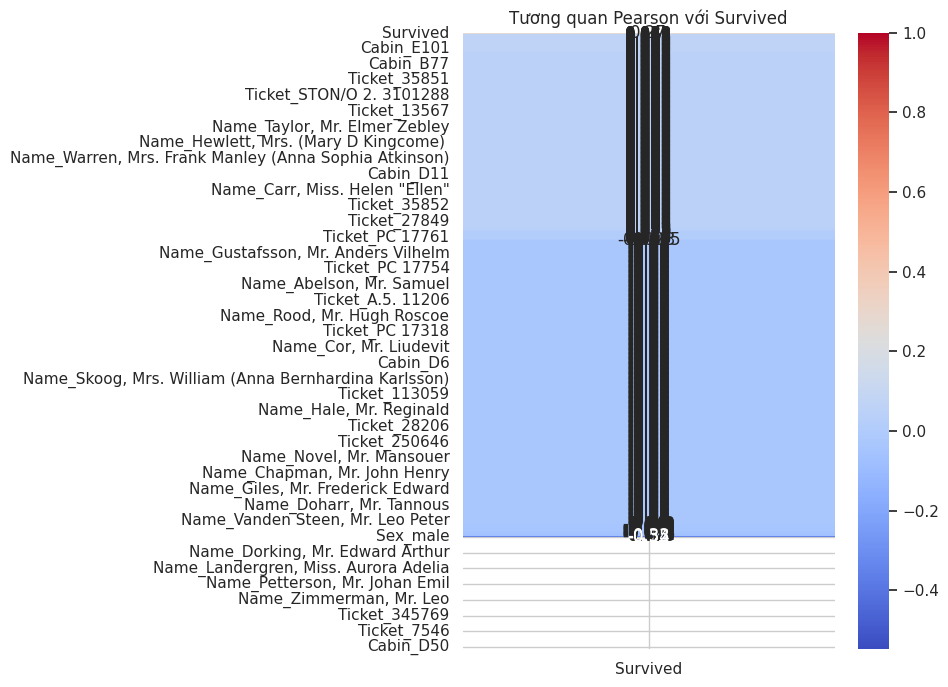

In [ ]:
# Tạo bản sao của X_train để phục vụ EDA tương quan, không làm thay đổi X_train gốc.
dftemp_eda = X_train.copy()
# Gắn nhãn Survived vào bản sao để tính tương quan giữa từng đặc trưng và biến mục tiêu.
dftemp_eda["Survived"] = y_train

# Tính ma trận tương quan Pearson cho các cột số.
corr = dftemp_eda.corr(numeric_only=True)
# Lấy riêng cột tương quan với Survived và sắp xếp giảm dần.
target_corr = corr["Survived"].sort_values(ascending=False)
# In tiêu đề cho bảng top đặc trưng tương quan.
print("Top 10 thuộc tính tương quan mạnh với Survived:")
# Hiển thị 10 giá trị tương quan cao nhất với Survived.
display(target_corr.head(10))

# Tạo khung hình cho heatmap tương quan.
plt.figure(figsize=(6, 8))
# Vẽ heatmap một cột thể hiện mức tương quan của từng đặc trưng với Survived.
sns.heatmap(
    # Sắp xếp các đặc trưng theo tương quan giảm dần để dễ đọc.
    corr[["Survived"]].sort_values(by="Survived", ascending=False),
    # Hiển thị trực tiếp hệ số tương quan trên heatmap.
    annot=True,
    # Dùng bảng màu coolwarm: màu nóng/lạnh thể hiện tương quan dương/âm.
    cmap="coolwarm"
)
# Đặt tiêu đề biểu đồ.
plt.title("Tương quan Pearson với Survived")
# Hiển thị heatmap.
plt.show()


### Output thu được và phân tích tương quan

**Cách đọc output**

Bảng `target_corr.head(10)` hiển thị 10 đặc trưng có tương quan Pearson cao nhất với `Survived`. Hệ số tương quan nằm trong khoảng từ -1 đến 1. Giá trị dương nghĩa là đặc trưng tăng thì khả năng `Survived = 1` có xu hướng tăng; giá trị âm nghĩa là xu hướng ngược lại.

**Một số kết quả đáng chú ý**

| Đặc trưng | Tương quan với `Survived` | Nhận định |
|---|---:|---|
| `Fare` | 0,271091 | Giá vé cao hơn thường gắn với khả năng sống sót cao hơn |
| `Parch` | 0,067785 | Quan hệ dương nhưng yếu |
| Một số cột `Ticket`/`Cabin` | Khoảng 0,067 - 0,083 | Có thể phản ánh nhóm hành khách hoặc vị trí khoang cụ thể |

Heatmap phía dưới là cách biểu diễn trực quan của cùng thông tin tương quan. Màu càng nghiêng về phía dương thì đặc trưng càng có quan hệ cùng chiều với `Survived`; màu càng nghiêng về phía âm thì quan hệ càng ngược chiều.

Do dữ liệu đã One-Hot nhiều cột có tần suất thấp, một số đặc trưng vé/khoang có tương quan dương nhưng cần diễn giải thận trọng. Tương quan Pearson chỉ đo quan hệ tuyến tính riêng lẻ, chưa phản ánh đầy đủ tương tác giữa giới tính, hạng vé, tuổi và giá vé.

**Kết luận:** `Fare` là tín hiệu rõ nhất trong nhóm tương quan cao, nhưng bài toán vẫn cần mô hình phân loại có khả năng kết hợp nhiều đặc trưng để dự đoán chính xác hơn.


<a id="muc-9"></a>
## 9. Huấn luyện và đánh giá mô hình Logistic Regression

Huấn luyện Logistic Regression làm mô hình phân loại cơ sở. Mô hình được đánh giá bằng `Accuracy`, `classification_report` và ma trận nhầm lẫn.


=== Logistic Regression ===
Accuracy: 0.7696629213483146

Classification report:
              precision    recall  f1-score   support

           0       0.78      0.87      0.82       110
           1       0.75      0.60      0.67        68

    accuracy                           0.77       178
   macro avg       0.76      0.74      0.75       178
weighted avg       0.77      0.77      0.76       178



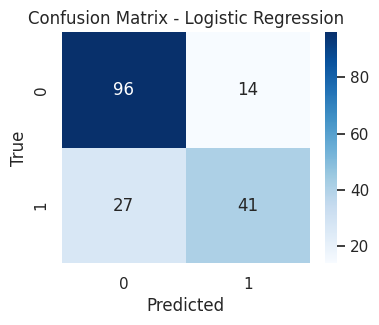

In [ ]:
# Khởi tạo mô hình Logistic Regression; max_iter=1000 giúp mô hình có đủ vòng lặp để hội tụ.
log_reg = LogisticRegression(max_iter=1000)
# Huấn luyện Logistic Regression trên tập train đã chuẩn hóa.
log_reg.fit(X_train, y_train)

# Dự đoán nhãn Survived cho tập validation.
y_pred_lr = log_reg.predict(X_val)

# In tên mô hình để phân biệt output đánh giá.
print("=== Logistic Regression ===")
# Tính và in Accuracy, tức tỷ lệ dự đoán đúng trên tập validation.
print("Accuracy:", accuracy_score(y_val, y_pred_lr))
# In tiêu đề cho báo cáo precision, recall và f1-score.
print("\nClassification report:")
# In báo cáo phân loại chi tiết cho từng lớp 0 và 1.
print(classification_report(y_val, y_pred_lr))

# Tính ma trận nhầm lẫn giữa nhãn thật và nhãn dự đoán.
cm_lr = confusion_matrix(y_val, y_pred_lr)
# Tạo khung hình nhỏ cho ma trận nhầm lẫn.
plt.figure(figsize=(4, 3))
# Vẽ heatmap ma trận nhầm lẫn, annot=True để hiện số lượng mẫu trong từng ô.
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues")
# Đặt tiêu đề biểu đồ.
plt.title("Confusion Matrix - Logistic Regression")
# Trục hoành là nhãn mô hình dự đoán.
plt.xlabel("Predicted")
# Trục tung là nhãn thực tế.
plt.ylabel("True")
# Hiển thị biểu đồ.
plt.show()


### Output thu được và đánh giá Logistic Regression

**Cách đọc output**

`Accuracy` là tỷ lệ dự đoán đúng trên toàn bộ tập validation. `classification_report` trình bày chi tiết hơn cho từng lớp: `precision` cho biết trong các mẫu mô hình dự đoán là một lớp thì có bao nhiêu mẫu đúng; `recall` cho biết trong các mẫu thật thuộc một lớp thì mô hình tìm đúng được bao nhiêu; `f1-score` là trung bình điều hòa giữa precision và recall.

**Kết quả mô hình cơ sở**

| Chỉ số | Giá trị | Ý nghĩa |
|---|---:|---|
| Accuracy | 0,7697 | Khoảng 76,97% mẫu validation được dự đoán đúng |
| Precision lớp 0 | 0,78 | Dự đoán không sống sót khá chính xác |
| Recall lớp 0 | 0,87 | Tìm đúng phần lớn hành khách không sống sót |
| F1-score lớp 0 | 0,82 | Hiệu quả lớp 0 tương đối tốt |
| Precision lớp 1 | 0,75 | Khi dự đoán sống sót, tỷ lệ đúng đạt 75% |
| Recall lớp 1 | 0,60 | Chỉ tìm đúng 60% hành khách thật sự sống sót |
| F1-score lớp 1 | 0,67 | Hiệu quả lớp sống sót còn thấp hơn lớp 0 |

Ma trận nhầm lẫn cho biết số lượng dự đoán đúng/sai theo từng lớp. Trục `True` là nhãn thật, trục `Predicted` là nhãn mô hình dự đoán. Các ô trên đường chéo là dự đoán đúng; các ô ngoài đường chéo là dự đoán sai.

Mô hình dự đoán tốt hơn ở lớp `0` với recall 0,87, trong khi recall lớp `1` chỉ đạt 0,60. Điều này cho thấy Logistic Regression còn bỏ sót khá nhiều hành khách thực sự sống sót.

**Kết luận:** Logistic Regression là mô hình phân loại cơ sở hợp lý, đạt độ chính xác khoảng **76,97%**, nhưng hiệu quả nhận diện lớp sống sót vẫn còn hạn chế.


<a id="muc-10"></a>
## 10. Huấn luyện và đánh giá mô hình Random Forest Classifier

Huấn luyện Random Forest với 200 cây quyết định để học các quan hệ phi tuyến và tương tác giữa đặc trưng. Mô hình được đánh giá bằng cùng bộ chỉ số để so sánh công bằng với Logistic Regression.


=== Random Forest ===
Accuracy: 0.8314606741573034

Classification report:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87       110
           1       0.82      0.72      0.77        68

    accuracy                           0.83       178
   macro avg       0.83      0.81      0.82       178
weighted avg       0.83      0.83      0.83       178



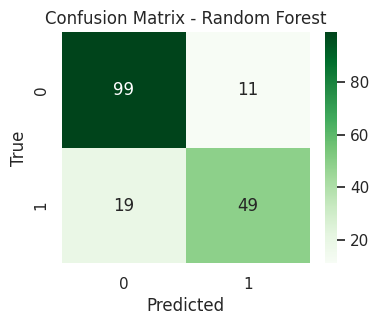

In [ ]:
# Khởi tạo mô hình Random Forest Classifier.
rf = RandomForestClassifier(
    # Sử dụng 200 cây quyết định trong rừng để tăng độ ổn định dự đoán.
    n_estimators=200,
    # Không giới hạn độ sâu cây, để cây có thể học các mẫu phức tạp trong dữ liệu.
    max_depth=None,
    # Cố định random_state để kết quả huấn luyện có thể lặp lại.
    random_state=42
)
# Huấn luyện Random Forest trên tập train đã chuẩn hóa.
rf.fit(X_train, y_train)

# Dự đoán nhãn Survived cho tập validation.
y_pred_rf = rf.predict(X_val)

# In tên mô hình để phân biệt output đánh giá.
print("=== Random Forest ===")
# Tính và in Accuracy của Random Forest trên tập validation.
print("Accuracy:", accuracy_score(y_val, y_pred_rf))
# In tiêu đề cho báo cáo phân loại chi tiết.
print("\nClassification report:")
# In precision, recall, f1-score và support cho từng lớp.
print(classification_report(y_val, y_pred_rf))

# Tính ma trận nhầm lẫn của Random Forest.
cm_rf = confusion_matrix(y_val, y_pred_rf)
# Tạo khung hình nhỏ cho heatmap ma trận nhầm lẫn.
plt.figure(figsize=(4, 3))
# Vẽ heatmap ma trận nhầm lẫn với tông màu xanh lá.
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens")
# Đặt tiêu đề biểu đồ.
plt.title("Confusion Matrix - Random Forest")
# Trục hoành là nhãn dự đoán.
plt.xlabel("Predicted")
# Trục tung là nhãn thật.
plt.ylabel("True")
# Hiển thị biểu đồ.
plt.show()


### Output thu được và đánh giá Random Forest Classifier

**Cách đọc output**

Các chỉ số được đọc giống Logistic Regression để có thể so sánh trực tiếp. Điểm cần chú ý nhất là Accuracy tổng thể và F1-score của lớp `1`, vì lớp `1` đại diện cho hành khách sống sót.

**Kết quả mô hình Random Forest**

| Chỉ số | Random Forest | Logistic Regression | Nhận xét |
|---|---:|---:|---|
| Accuracy | 0,8315 | 0,7697 | Tăng khoảng 6,18 điểm phần trăm |
| F1-score lớp 0 | 0,87 | 0,82 | Cải thiện nhóm không sống sót |
| F1-score lớp 1 | 0,77 | 0,67 | Cải thiện rõ nhóm sống sót |
| Recall lớp 1 | 0,72 | 0,60 | Bỏ sót ít hành khách sống sót hơn |

Ma trận nhầm lẫn của Random Forest cũng được đọc theo nguyên tắc: ô đường chéo là đúng, ô ngoài đường chéo là sai. So với Logistic Regression, Random Forest dự đoán cân bằng hơn giữa hai lớp và cải thiện rõ ở lớp sống sót.

Random Forest đạt kết quả tốt hơn Logistic Regression trên hầu hết chỉ số. Mô hình cây có lợi thế trong việc học quan hệ phi tuyến và tương tác giữa các đặc trưng, ví dụ kết hợp giữa hạng vé, giới tính, tuổi, giá vé và thông tin khoang.

**Kết luận:** Trong phạm vi thực nghiệm của notebook, Random Forest Classifier là mô hình phân loại tốt hơn và phù hợp để chọn làm mô hình cuối cùng.


<a id="muc-11"></a>
## 11. So sánh kết quả và kết luận bài toán phân loại

Đề tài đã xây dựng quy trình giải quyết **bài toán phân loại dự đoán sống sót Titanic**, trong đó biến mục tiêu `Survived` là nhãn nhị phân. Dữ liệu gốc có 891 hành khách và 12 cột; sau khi tách nhãn, xử lý giá trị thiếu, loại 3 ngoại lệ theo `Fare`, mã hóa One-Hot, chia train/validation và chuẩn hóa, hai mô hình phân loại đã được huấn luyện trên cùng điều kiện.

`LogisticRegression` đạt `Accuracy = 0,7697`, đóng vai trò mô hình cơ sở dễ diễn giải. Tuy nhiên, mô hình này nhận diện lớp sống sót chưa tốt, với recall lớp `1` bằng 0,60.

`RandomForestClassifier` đạt `Accuracy = 0,8315`, F1-score lớp `1` bằng 0,77 và recall lớp `1` bằng 0,72. Kết quả này tốt hơn Logistic Regression, đặc biệt ở khả năng phát hiện hành khách sống sót.

Như vậy, báo cáo thuộc **bài toán phân loại nhị phân**: cả hai thuật toán đều dự đoán nhãn `Survived` thay vì một giá trị liên tục. Dựa trên kết quả validation hiện có, **Random Forest Classifier được đề xuất làm mô hình phân loại cuối cùng**, còn Logistic Regression là mô hình cơ sở để so sánh.

#### Hạn chế và hướng phát triển

- One-Hot trực tiếp `Name`, `Ticket` và `Cabin` tạo số lượng đặc trưng rất lớn; có thể cải thiện bằng feature engineering như tách danh xưng, nhóm cabin hoặc nhóm loại vé.
- Kết quả hiện dựa trên một lần chia train/validation; có thể dùng cross-validation để kết luận ổn định hơn.
- Có thể bổ sung tuning tham số cho Random Forest hoặc thử các mô hình boosting như Gradient Boosting, XGBoost, LightGBM để cải thiện hiệu quả phân loại.

#### Bảng tổng hợp kết quả cuối

| Mô hình | Loại bài toán | Accuracy | F1-score lớp 0 | F1-score lớp 1 | Nhận xét |
|---|---|---:|---:|---:|---|
| Logistic Regression | Phân loại nhị phân | 0,7697 | 0,82 | 0,67 | Mô hình cơ sở, kết quả ổn nhưng nhận diện lớp sống sót còn hạn chế |
| Random Forest Classifier | Phân loại nhị phân | 0,8315 | 0,87 | 0,77 | Dự đoán tốt hơn, đặc biệt cải thiện nhóm hành khách sống sót |

**Kết luận chọn mô hình:** `RandomForestClassifier` là mô hình phù hợp hơn cho đề tài dự đoán sống sót Titanic vì đạt Accuracy và F1-score cao hơn Logistic Regression.
